In [1]:
import torch
import numpy as np
import random

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [2]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
import sys
!{sys.executable} -m pip install torch "gluonts[torch]"

In [4]:
import pandas as pd
import numpy as np
from gluonts.dataset.common import ListDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.evaluation import make_evaluation_predictions, Evaluator
import statsmodels.formula.api as smf
import gc
import os

In [5]:
# load data
os.chdir("/Users/conniezhang/Desktop/ECON491/data/")

sales_train = pd.read_csv("Sales Train Validation.csv")
calendar = pd.read_csv("Calendar (1).csv")
prices = pd.read_csv("sell_prices.csv")

In [6]:
# process the sales data

# Drop unused columns to save RAM immediately
sales_train = sales_train.drop(columns=["cat_id", "state_id"])

# Find all the day columns (d_1, d_2, etc.)
day_cols = [col for col in sales_train.columns if col.startswith('d_')]

# Melt the dataframe (equivalent to your long_sales in R)
long_sales = pd.melt(
    sales_train, 
    id_vars=['item_id', 'dept_id', 'store_id'], 
    value_vars=day_cols, 
    var_name='d', 
    value_name='sales'
)

# Clear old wide data from RAM
del sales_train
gc.collect()

80

In [7]:
# prepare calendar data and join
calendar['d'] = 'd_' + (calendar.index + 1).astype(str)

# Keep only what we need
slim_calendar = calendar[['d', 'date', 'wm_yr_wk', 'wday', 'month', 'event_type_1']].copy()
slim_calendar['date'] = pd.to_datetime(slim_calendar['date'])

# Merge sales and calendar (like your on="d" join)
final_df = pd.merge(long_sales, slim_calendar, on='d', how='left')

del long_sales, slim_calendar
gc.collect()

0

In [8]:
# get average price for each item/store combination
# Get lifetime sales per item for weights
item_weights = final_df.groupby(['item_id', 'store_id', 'dept_id'])['sales'].sum().reset_index(name='item_lifetime_sales')

# Merge prices with weights
prices_mapped = pd.merge(prices, item_weights, on=['item_id', 'store_id'])

# Calculate weighted average price per department per week
prices_mapped['weighted_price'] = prices_mapped['sell_price'] * prices_mapped['item_lifetime_sales']
dept_prices = prices_mapped.groupby(['store_id', 'dept_id', 'wm_yr_wk']).apply(
    lambda x: x['weighted_price'].sum() / x['item_lifetime_sales'].sum()
).reset_index(name='avg_price')

del prices, prices_mapped, item_weights
gc.collect()

0

In [9]:
# assemble model data
# Aggregate daily sales to store-dept level
model_data = final_df.groupby(['store_id', 'dept_id', 'date', 'wm_yr_wk', 'wday', 'month', 'event_type_1'], dropna=False)['sales'].sum().reset_index(name='total_sales')

# Join prices
model_data = pd.merge(model_data, dept_prices, on=['store_id', 'dept_id', 'wm_yr_wk'], how='left')

# Drop rows with missing prices
model_data = model_data.dropna(subset=['avg_price'])

# Create Dummy Variables for the Econometrics Model
model_data['day_of_week'] = model_data['wday'].astype(str) # Treat as categorical
model_data['month_factor'] = model_data['month'].astype(str) # Treat as categorical
model_data['is_holiday'] = np.where(model_data['event_type_1'].isna(), 0, 1) # 1 if event, 0 if normal

In [10]:
# train/test split
split_date = pd.to_datetime("2016-04-24")
train_data = model_data[model_data['date'] <= split_date]
test_data = model_data[model_data['date'] > split_date].copy()

In [11]:
# run the simple benchmark model
# In Python's statsmodels, 'C()' tells it to treat a variable as a categorical factor (dummy variable)
formula = "total_sales ~ avg_price + C(day_of_week) + C(month_factor) + is_holiday"

# Fit the model
simple_model = smf.ols(formula=formula, data=train_data).fit()

# Print the beautiful Econometrics summary table!
print(simple_model.summary())

                            OLS Regression Results                            
Dep. Variable:            total_sales   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     984.3
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:07:58   Log-Likelihood:            -1.0384e+06
No. Observations:              133910   AIC:                         2.077e+06
Df Residuals:                  133890   BIC:                         2.077e+06
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              1263.42

In [12]:
# reshaping data for deepAR
ts_data = model_data.pivot_table(
    index='date', 
    columns=['store_id', 'dept_id'], 
    values='total_sales', 
    aggfunc='sum'
)

# 1. Convert to datetime
ts_data.index = pd.to_datetime(ts_data.index)

# 2. Force daily frequency (this might create rows with NaNs for missing days)
ts_data = ts_data.asfreq('D')

# 3. NOW fill everything with 0 (this catches both original missing data AND new missing days)
ts_data = ts_data.fillna(0)

# Preview the data
ts_data.iloc[:5, :4]

store_id      CA_1                          
dept_id    FOODS_1 FOODS_2 FOODS_3 HOBBIES_1
date                                        
2011-01-29     297     674    2268       528
2011-01-30     284     655    2198       489
2011-01-31     214     396    1398       409
2011-02-01     175     476    1607       383
2011-02-02     182     354    1496       263

In [13]:
# 1. Get a list of all unique departments from your pivot table
departments = ts_data.columns.get_level_values('dept_id').unique()

# 2. Create dictionaries to store your trained models and datasets
trained_predictors = {}
test_datasets = {}

prediction_length = 28
split_date = pd.to_datetime("2016-04-24")

# 3. Loop through each department and train a separate model
for dept in departments:
    print(f"--- Preparing and Training Model for Department: {dept} ---")
    
    # Isolate the data just for this department across all stores
    # .xs grabs a "cross-section" of your MultiIndex columns
    dept_ts_data = ts_data.xs(dept, level='dept_id', axis=1)
    
    # Split train/test for this specific department
    train_dept_ts = dept_ts_data[dept_ts_data.index <= split_date]
    test_dept_ts = dept_ts_data
    
    # Create GluonTS Datasets
    train_ds = ListDataset(
        [{"start": train_dept_ts.index[0], "target": train_dept_ts[col].values} for col in train_dept_ts.columns],
        freq="D"
    )
    
    test_ds = ListDataset(
        [{"start": test_dept_ts.index[0], "target": test_dept_ts[col].values} for col in test_dept_ts.columns],
        freq="D"
    )
    
    # Initialize the DeepAR model for this department
    estimator = DeepAREstimator(
        freq="D",
        prediction_length=prediction_length,
        context_length=prediction_length * 2, 
        num_layers=2,
        hidden_size=32,
        trainer_kwargs={
            "max_epochs": 15,  # You might want to lower this so the loop doesn't take hours!
            "accelerator": "cpu",
            "enable_progress_bar": False
        } 
    )
    
    # Train the model
    predictor = estimator.train(train_ds)
    
    # Save the trained predictor and test dataset to our dictionaries
    trained_predictors[dept] = predictor
    test_datasets[dept] = test_ds

print("All Department Models Trained Successfully!")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type        | Params | Mode  | In sizes                                                         | Out sizes   
--------------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 17.6 K | train | [[1, 1], [1, 1], [1, 1148, 4], [1, 1148], [1, 1148], [1, 28, 4]] | [1, 100, 28]
--------------------------------------------------------------------------------------------------------------------------------
17.6 K    Trainable params
0         Non-trainable params
17.6 K    Total params
0.071     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


--- Preparing and Training Model for Department: FOODS_1 ---


Epoch 0, global step 50: 'train_loss' reached 6.22353 (best 6.22353), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_25/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 5.47165 (best 5.47165), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_25/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 5.42801 (best 5.42801), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_25/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 5.34813 (best 5.34813), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_25/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 5.28710 (best 5.28710), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_25/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5, glo

--- Preparing and Training Model for Department: FOODS_2 ---


Epoch 0, global step 50: 'train_loss' reached 6.66480 (best 6.66480), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_26/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 5.77745 (best 5.77745), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_26/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 5.56568 (best 5.56568), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_26/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 5.54209 (best 5.54209), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_26/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 5.47958 (best 5.47958), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_26/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5, glo

...

--- Preparing and Training Model for Department: HOUSEHOLD_1 ---


Epoch 0, global step 50: 'train_loss' reached 6.97734 (best 6.97734), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_30/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 6.16057 (best 6.16057), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_30/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 5.81472 (best 5.81472), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_30/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 5.75054 (best 5.75054), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_30/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 5.70986 (best 5.70986), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_30/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5, glo

--- Preparing and Training Model for Department: HOUSEHOLD_2 ---


Epoch 0, global step 50: 'train_loss' reached 5.44436 (best 5.44436), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_31/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 4.89822 (best 4.89822), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_31/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 4.72725 (best 4.72725), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_31/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 4.54978 (best 4.54978), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_31/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 4.49688 (best 4.49688), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_31/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5, glo

All Department Models Trained Successfully!


In [14]:
# Create variables to help us calculate the overall average later
total_mape = 0
total_rmse = 0
num_departments = len(trained_predictors)

print("--- Department Evaluation Report ---")

# Loop through every department we trained
for dept in trained_predictors.keys():
    
    # 1. Grab the specific model and test data for THIS department
    current_predictor = trained_predictors[dept]
    current_test_ds = test_datasets[dept]
    
    # 2. This is YOUR exact code, just using the current department's data!
    forecast_it, ts_it = make_evaluation_predictions(
        dataset=current_test_ds,  
        predictor=current_predictor,  
        num_samples=100,  
    )
    
    forecasts = list(forecast_it)
    tss = list(ts_it)
    
    evaluator = Evaluator(quantiles=[0.5]) 
    agg_metrics, item_metrics = evaluator(tss, forecasts)
    
    # 3. Print the results for this specific department
    print(f"Department {dept} | RMSE: {agg_metrics['RMSE']:.2f} | MAPE: {agg_metrics['MAPE'] * 100:.2f}%")
    
    # Add to our running totals
    total_mape += agg_metrics['MAPE'] * 100
    total_rmse += agg_metrics['RMSE']

# 4. Calculate and print the grand totals for your presentation!
print("-" * 40)
print(f"OVERALL AVERAGE RMSE: {total_rmse / num_departments:.2f}")
print(f"OVERALL AVERAGE MAPE: {total_mape / num_departments:.2f}%")
print("-" * 40)

--- Department Evaluation Report ---


Running evaluation: 10it [00:00, 90.85it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


Department FOODS_1 | RMSE: 63.27 | MAPE: 18.38%


Running evaluation: 10it [00:00, 119.23it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


Department FOODS_2 | RMSE: 98.53 | MAPE: 9.98%


...

Running evaluation: 10it [00:00, 123.37it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


Department HOUSEHOLD_1 | RMSE: 97.58 | MAPE: 8.60%


Running evaluation: 10it [00:00, 142.26it/s]


Department HOUSEHOLD_2 | RMSE: 28.32 | MAPE: 10.45%
----------------------------------------
OVERALL AVERAGE RMSE: 79.42
OVERALL AVERAGE MAPE: 13.56%
----------------------------------------


/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


In [15]:
# 1. Pivot the price data
price_data = model_data.pivot_table(
    index='date', 
    columns=['store_id', 'dept_id'], 
    values='avg_price', 
    aggfunc='mean'
)

# 2. Convert to datetime
price_data.index = pd.to_datetime(price_data.index)

# 3. Force continuous daily calendar (this adds NaNs for days with no sales data)
price_data = price_data.asfreq('D')

# 4. NOW fill the missing values 
# 'ffill' carries yesterday's price forward for missing days. 
# The .fillna(0) catches any items that had no price on the very first day.
price_data = price_data.fillna(method='ffill').fillna(0)

In [16]:
# 1. Get a list of all unique departments from your pivot table
departments = ts_data.columns.get_level_values('dept_id').unique()

# 2. Create dictionaries to store your trained Econ models and datasets
trained_econ_predictors = {}
test_econ_datasets = {}

prediction_length = 28
split_date = pd.to_datetime("2016-04-24")

# 3. Loop through each department and train a separate Econ model
for dept in departments:
    print(f"--- Preparing and Training Econ Model for Department: {dept} ---")
    
    # Isolate SALES data for this department
    dept_ts_data = ts_data.xs(dept, level='dept_id', axis=1)
    train_dept_ts = dept_ts_data[dept_ts_data.index <= split_date]
    test_dept_ts = dept_ts_data
    
    # *** CHANGE 1: Isolate PRICE data for this department ***
    # (Assuming you already created 'price_data' from Cell 18)
    dept_price_data = price_data.xs(dept, level='dept_id', axis=1)
    train_dept_price = dept_price_data[dept_price_data.index <= split_date]
    test_dept_price = dept_price_data
    
    # *** CHANGE 2: Inject price into the Datasets ***
    train_ds_econ = ListDataset(
        [
            {
                "start": train_dept_ts.index[0], 
                "target": train_dept_ts[col].values,
                "feat_dynamic_real": [train_dept_price[col].values]
            } 
            for col in train_dept_ts.columns
        ],
        freq="D"
    )
    
    test_ds_econ = ListDataset(
        [
            {
                "start": test_dept_ts.index[0], 
                "target": test_dept_ts[col].values,
                "feat_dynamic_real": [test_dept_price[col].values]
            } 
            for col in test_dept_ts.columns
        ],
        freq="D"
    )
    
    # *** CHANGE 3: Update Estimator for dynamic features ***
    estimator_econ = DeepAREstimator(
        freq="D",
        prediction_length=prediction_length,
        context_length=prediction_length * 2, 
        num_feat_dynamic_real=1,  # <--- Telling the AI to expect the price data
        num_layers=2,
        hidden_size=32,
        trainer_kwargs={
            "max_epochs": 15, 
            "accelerator": "cpu",
            "enable_progress_bar": False
        } 
    )
    
    # Train the model
    predictor_econ = estimator_econ.train(train_ds_econ)
    
    # Save the trained predictor and test dataset
    trained_econ_predictors[dept] = predictor_econ
    test_econ_datasets[dept] = test_ds_econ

print("All Advanced Econ Department Models Trained Successfully!")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type        | Params | Mode  | In sizes                                                         | Out sizes   
--------------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 17.8 K | train | [[1, 1], [1, 1], [1, 1148, 5], [1, 1148], [1, 1148], [1, 28, 5]] | [1, 100, 28]
--------------------------------------------------------------------------------------------------------------------------------
17.8 K    Trainable params
0         Non-trainable params
17.8 K    Total params
0.071     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


--- Preparing and Training Econ Model for Department: FOODS_1 ---


Epoch 0, global step 50: 'train_loss' reached 6.03672 (best 6.03672), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_32/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 5.49688 (best 5.49688), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_32/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 5.43872 (best 5.43872), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_32/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 5.30663 (best 5.30663), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_32/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 5.24858 (best 5.24858), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_32/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5, glo

--- Preparing and Training Econ Model for Department: FOODS_2 ---


Epoch 0, global step 50: 'train_loss' reached 6.54843 (best 6.54843), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_33/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 5.86678 (best 5.86678), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_33/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 5.60667 (best 5.60667), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_33/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 5.52081 (best 5.52081), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_33/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 5.50828 (best 5.50828), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_33/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5, glo

...

--- Preparing and Training Econ Model for Department: HOUSEHOLD_1 ---


Epoch 0, global step 50: 'train_loss' reached 6.75874 (best 6.75874), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_37/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 6.18179 (best 6.18179), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_37/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 5.94011 (best 5.94011), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_37/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 5.83498 (best 5.83498), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_37/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 5.79608 (best 5.79608), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_37/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5, glo

--- Preparing and Training Econ Model for Department: HOUSEHOLD_2 ---


Epoch 0, global step 50: 'train_loss' reached 5.44254 (best 5.44254), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_38/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 4.87805 (best 4.87805), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_38/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 4.71577 (best 4.71577), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_38/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 4.52975 (best 4.52975), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_38/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 4.51503 (best 4.51503), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_38/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5, glo

All Advanced Econ Department Models Trained Successfully!


In [17]:
# Create variables to track our overall averages for the Econ model
total_econ_mape = 0
total_econ_rmse = 0
num_departments = len(trained_econ_predictors)

print("--- Advanced (Econ) Department Evaluation Report ---")

# Loop through every Econ model we just trained
for dept in trained_econ_predictors.keys():
    
    # 1. Grab the specific Econ model and test data for THIS department
    current_predictor = trained_econ_predictors[dept]
    current_test_ds = test_econ_datasets[dept]
    
    # 2. Generate predictions
    forecast_it, ts_it = make_evaluation_predictions(
        dataset=current_test_ds,  
        predictor=current_predictor,  
        num_samples=100,  
    )
    
    forecasts = list(forecast_it)
    tss = list(ts_it)
    
    evaluator = Evaluator(quantiles=[0.5]) 
    agg_metrics, item_metrics = evaluator(tss, forecasts)
    
    # 3. Print the results for this specific department
    print(f"Department {dept} | Econ RMSE: {agg_metrics['RMSE']:.2f} | Econ MAPE: {agg_metrics['MAPE'] * 100:.2f}%")
    
    # Add to our running totals
    total_econ_mape += agg_metrics['MAPE'] * 100
    total_econ_rmse += agg_metrics['RMSE']

# 4. Calculate and print the grand totals!
print("-" * 40)
print(f"OVERALL ECON AVERAGE RMSE: {total_econ_rmse / num_departments:.2f}")
print(f"OVERALL ECON AVERAGE MAPE: {total_econ_mape / num_departments:.2f}%")
print("-" * 40)

--- Advanced (Econ) Department Evaluation Report ---


Running evaluation: 10it [00:00, 108.41it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


Department FOODS_1 | Econ RMSE: 67.66 | Econ MAPE: 19.19%


Running evaluation: 10it [00:00, 104.24it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


Department FOODS_2 | Econ RMSE: 93.83 | Econ MAPE: 10.54%


...

Running evaluation: 10it [00:00, 97.61it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


Department HOUSEHOLD_1 | Econ RMSE: 91.72 | Econ MAPE: 8.31%


Running evaluation: 10it [00:00, 119.89it/s]


Department HOUSEHOLD_2 | Econ RMSE: 29.81 | Econ MAPE: 10.69%
----------------------------------------
OVERALL ECON AVERAGE RMSE: 78.47
OVERALL ECON AVERAGE MAPE: 13.59%
----------------------------------------


/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


In [19]:
from gluonts.evaluation import Evaluator

print("=" * 60)
print("FINAL OVERFITTING REPORT: TRAIN VS TEST".center(60))
print("=" * 60)

# Make sure we use the same split date as before
split_date = pd.to_datetime("2016-04-24")
evaluator = Evaluator(quantiles=[0.5])

for dept in departments:
    print(f"\n--- Analyzing Department: {dept} ---")
    
    # 1. Recreate the Training Data for this department (Base Model)
    dept_ts_data = ts_data.xs(dept, level='dept_id', axis=1)
    train_dept_ts = dept_ts_data[dept_ts_data.index <= split_date]
    train_ds_base = ListDataset(
        [{"start": train_dept_ts.index[0], "target": train_dept_ts[col].values} for col in train_dept_ts.columns],
        freq="D"
    )
    
    # 2. Recreate the Training Data for this department (Econ Model with Price)
    dept_price_data = price_data.xs(dept, level='dept_id', axis=1)
    train_dept_price = dept_price_data[dept_price_data.index <= split_date]
    train_ds_econ = ListDataset(
        [
            {
                "start": train_dept_ts.index[0], 
                "target": train_dept_ts[col].values,
                "feat_dynamic_real": [train_dept_price[col].values]
            } 
            for col in train_dept_ts.columns
        ],
        freq="D"
    )
    
    # --- EVALUATE BASE MODEL (TRAIN VS TEST) ---
    # Train
    fcst_train_base, ts_train_base = make_evaluation_predictions(dataset=train_ds_base, predictor=trained_predictors[dept], num_samples=100)
    metrics_train_base, _ = evaluator(list(ts_train_base), list(fcst_train_base))
    
    # Test (using the test datasets we saved earlier)
    fcst_test_base, ts_test_base = make_evaluation_predictions(dataset=test_datasets[dept], predictor=trained_predictors[dept], num_samples=100)
    metrics_test_base, _ = evaluator(list(ts_test_base), list(fcst_test_base))

    # --- EVALUATE ECON MODEL (TRAIN VS TEST) ---
    # Train
    fcst_train_econ, ts_train_econ = make_evaluation_predictions(dataset=train_ds_econ, predictor=trained_econ_predictors[dept], num_samples=100)
    metrics_train_econ, _ = evaluator(list(ts_train_econ), list(fcst_train_econ))
    
    # Test
    fcst_test_econ, ts_test_econ = make_evaluation_predictions(dataset=test_econ_datasets[dept], predictor=trained_econ_predictors[dept], num_samples=100)
    metrics_test_econ, _ = evaluator(list(ts_test_econ), list(fcst_test_econ))

    # --- PRINT THE RESULTS ---
    print("  [Base DeepAR]")
    print(f"    Train MAPE: {metrics_train_base['MAPE']*100:.2f}%  |  Test MAPE: {metrics_test_base['MAPE']*100:.2f}%")
    
    print("  [Advanced Econ DeepAR (w/ Price)]")
    print(f"    Train MAPE: {metrics_train_econ['MAPE']*100:.2f}%  |  Test MAPE: {metrics_test_econ['MAPE']*100:.2f}%")
    
print("\n" + "=" * 60)
print("REPORT COMPLETE")

          FINAL OVERFITTING REPORT: TRAIN VS TEST           

--- Analyzing Department: FOODS_1 ---


Running evaluation: 10it [00:00, 109.05it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 154.72it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 68.51it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 95.64it/s]
/opt/miniconda3/envs/econ491_walmart_forcasti

  [Base DeepAR]
    Train MAPE: 17.90%  |  Test MAPE: 18.47%
  [Advanced Econ DeepAR (w/ Price)]
    Train MAPE: 18.74%  |  Test MAPE: 19.00%

--- Analyzing Department: FOODS_2 ---


Running evaluation: 10it [00:00, 99.04it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 147.87it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 143.24it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 141.77it/s]
/opt/miniconda3/envs/econ491_walmart_forcast

  [Base DeepAR]
    Train MAPE: 10.13%  |  Test MAPE: 10.09%
  [Advanced Econ DeepAR (w/ Price)]
    Train MAPE: 10.56%  |  Test MAPE: 10.53%

--- Analyzing Department: FOODS_3 ---


...

Running evaluation: 10it [00:00, 102.36it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 148.62it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 147.36it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 115.77it/s]
/opt/miniconda3/envs/econ491_walmart_forcas

  [Base DeepAR]
    Train MAPE: 8.53%  |  Test MAPE: 8.74%
  [Advanced Econ DeepAR (w/ Price)]
    Train MAPE: 8.31%  |  Test MAPE: 8.35%

--- Analyzing Department: HOUSEHOLD_2 ---


Running evaluation: 10it [00:00, 121.80it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 126.93it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 93.60it/s]
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
Running evaluation: 10it [00:00, 111.72it/s]


  [Base DeepAR]
    Train MAPE: 10.54%  |  Test MAPE: 10.51%
  [Advanced Econ DeepAR (w/ Price)]
    Train MAPE: 10.76%  |  Test MAPE: 10.77%

REPORT COMPLETE


/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


Generating plot for FOODS_1...


<Figure size 1200x600 with 0 Axes>

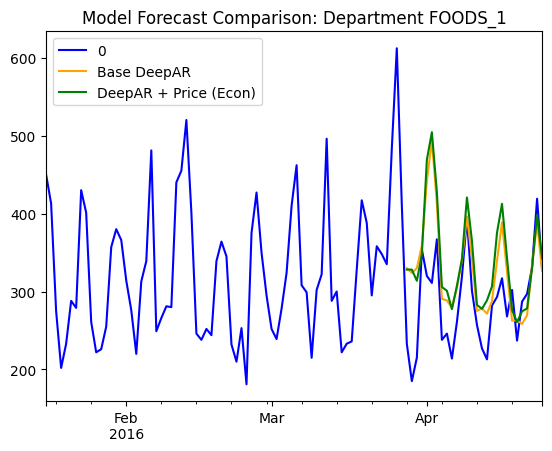

In [20]:
import matplotlib.pyplot as plt

# 1. Choose which department you want to visualize for your presentation
target_dept = "FOODS_1"  # Change this to 'HOBBIES_1', 'FOODS_2', etc., to see different charts!

print(f"Generating plot for {target_dept}...")

# 2. Grab predictions for the Base Model
forecast_it_base, ts_it_base = make_evaluation_predictions(
    dataset=test_datasets[target_dept],
    predictor=trained_predictors[target_dept],
    num_samples=100,
)
forecasts_base = list(forecast_it_base)
tss_base = list(ts_it_base)

# 3. Grab predictions for the Advanced (Econ) Model
forecast_it_econ, ts_it_econ = make_evaluation_predictions(
    dataset=test_econ_datasets[target_dept],
    predictor=trained_econ_predictors[target_dept],
    num_samples=100,
)
forecasts_econ = list(forecast_it_econ)

# 4. Extract the first store's time series from this specific department
ts = tss_base[0]
forecast_base = forecasts_base[0]
forecast_econ = forecasts_econ[0]

# 5. Plot the results!
plt.figure(figsize=(12,6))

# Actual values (looking at the last 100 days so we can see the forecast clearly)
ts[-100:].plot(color='blue', label="Actual Sales")

# Base model prediction (median)
plt.plot(forecast_base.index, forecast_base.quantile(0.5), color='orange', label="Base DeepAR")

# Econ model prediction (median)
plt.plot(forecast_econ.index, forecast_econ.quantile(0.5), color='green', label="DeepAR + Price (Econ)")

plt.title(f"Model Forecast Comparison: Department {target_dept}")
plt.legend()
plt.show()